# Etapa 0

Carregamento de bibliotecas

In [1]:
import cv2
import random
from pathlib import Path

# Etapa 1

Foram coletadas 6 imagens em resolução 4032x3024. Para melhor performance, as imagens serão redimensionadas com o fator x0.25, utilizando Lanczos.

## Redimensionamento

In [2]:
from src.resize import resize_images

images_raw_dir = Path("./data/raw/")
images_processed_dir = Path("./data/processed")

resize_images(images_raw_dir, images_processed_dir, 0.25)

IMG_0301.JPG: 4032×3024 → 1008×756
IMG_0302.JPG: 4032×3024 → 1008×756
IMG_0303.JPG: 4032×3024 → 1008×756
IMG_0304.JPG: 4032×3024 → 1008×756
IMG_0305.JPG: 4032×3024 → 1008×756
IMG_0306.JPG: 4032×3024 → 1008×756
IMG_0307.JPG: 4032×3024 → 1008×756
IMG_0315.JPG: 4032×3024 → 1008×756


## Carregregamento das imagens

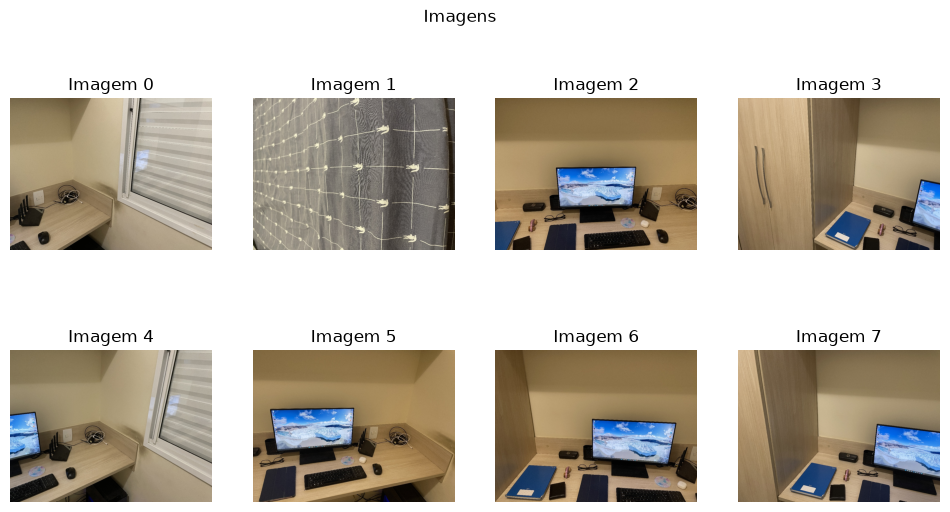

In [3]:
from src.visualization import plot_image_grid

images = []
for image_path in sorted(images_processed_dir.iterdir()):
    image = cv2.imread(image_path)
    images.append(image)

random.seed(2026)
random.shuffle(images)
plot_image_grid(images)

## Panorama do OpenCV

Este é o panorama criado utilizando a implementação nativa do OpenCV, apenas para critério de comparação.

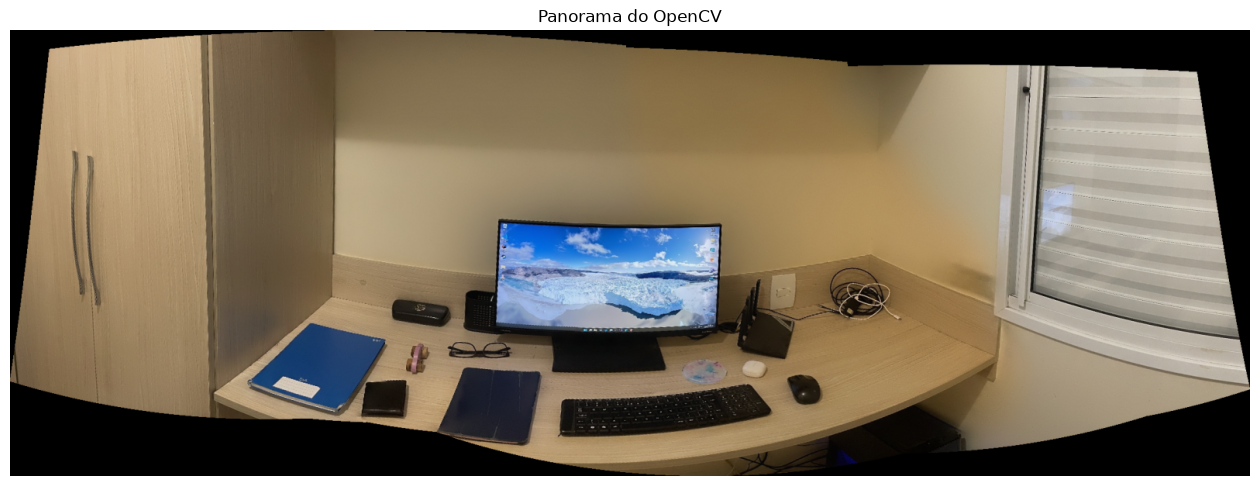

In [4]:
from src.visualization import plot_image

stitcher = cv2.Stitcher_create(cv2.Stitcher_PANORAMA)
status, panorama_opencv = stitcher.stitch(images)

if status == cv2.Stitcher_OK:
    plot_image(panorama_opencv, "Panorama do OpenCV")
    cv2.imwrite("results/panorama_opencv.jpg", panorama_opencv)
else:
    print("O Stitcher falhou.")

# Etapa 2

Detecção de keypoints com SIFT e ORB

Detector: sift


  Número de keypoints: 535
  Formato dos descritores: (535, 128)
  Número de keypoints: 3000
  Formato dos descritores: (3000, 128)
  Número de keypoints: 1004
  Formato dos descritores: (1004, 128)
  Número de keypoints: 476
  Formato dos descritores: (476, 128)
  Número de keypoints: 754
  Formato dos descritores: (754, 128)
  Número de keypoints: 1142
  Formato dos descritores: (1142, 128)
  Número de keypoints: 899
  Formato dos descritores: (899, 128)
  Número de keypoints: 820
  Formato dos descritores: (820, 128)


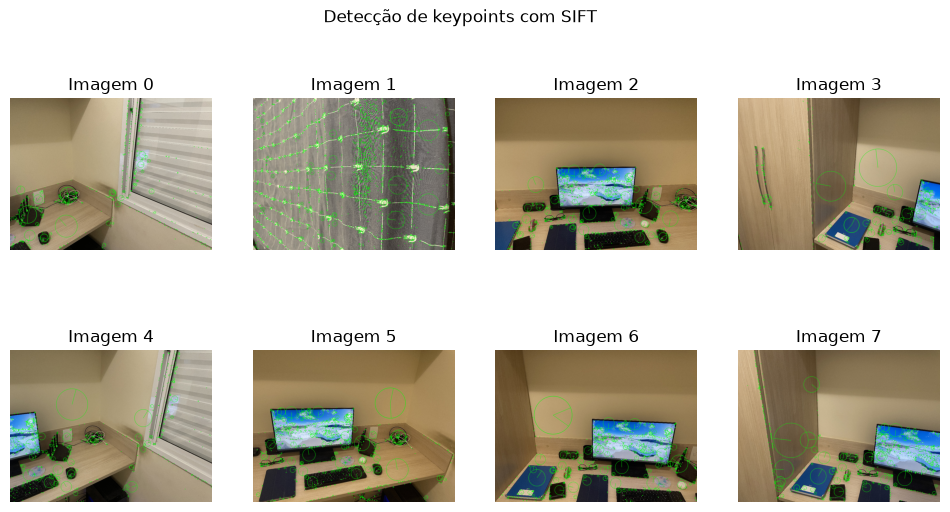

In [5]:
from src.features import draw_keypoints

images_sift = draw_keypoints(images, "sift") # array de dicts contendo { "image": (valor),  "keypoints": (valor), "descriptors": (valor) }

plot_image_grid([item["image"] for item in images_sift], "Detecção de keypoints com SIFT") # extrai "image" de cada item no array

Detector: orb
  Número de keypoints: 500
  Formato dos descritores: (500, 32)
  Número de keypoints: 500
  Formato dos descritores: (500, 32)


  Número de keypoints: 500
  Formato dos descritores: (500, 32)
  Número de keypoints: 500
  Formato dos descritores: (500, 32)
  Número de keypoints: 500
  Formato dos descritores: (500, 32)
  Número de keypoints: 500
  Formato dos descritores: (500, 32)
  Número de keypoints: 500
  Formato dos descritores: (500, 32)
  Número de keypoints: 500
  Formato dos descritores: (500, 32)


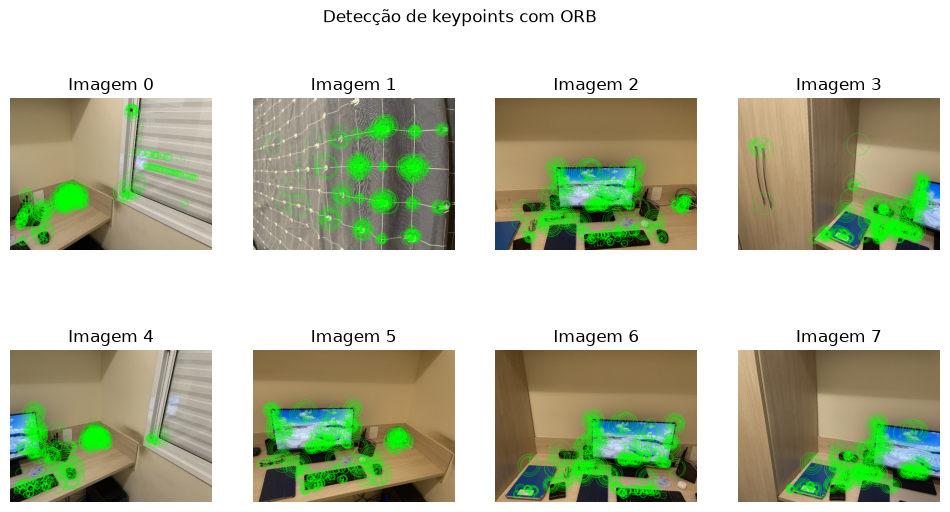

In [6]:
images_orb = draw_keypoints(images, "orb") # array de dicts contendo { "image": (valor),  "keypoints": (valor), "descriptors": (valor) }
plot_image_grid([item["image"] for item in images_orb], "Detecção de keypoints com ORB") # extrai "image" de cada item no array

# Etapa 3

In [7]:
keypoints = [item["keypoints"] for item in images_sift]
descriptors = [item["descriptors"] for item in images_sift]

In [8]:
from src.matching import match_all_images

RATIO_THRESHOLD = 0.8

matches_matrix, lowe_matrix= match_all_images(
    descriptors,
    method="sift",
    ratio=RATIO_THRESHOLD
)

print("Sem o teste de Lowe")
for i in range(len(matches_matrix)):
    for j in range(len(matches_matrix[i])):
        print(
            f"Imagem {i} <-> Imagem {j}: "
            f"{len(matches_matrix[i][j])} matches"
        )

print("Com o teste de Lowe")
for i in range(len(lowe_matrix)):
    for j in range(len(lowe_matrix[i])):
        print(
            f"Imagem {i} <-> Imagem {j}: "
            f"{len(lowe_matrix[i][j])} matches"
        )

Sem o teste de Lowe
Imagem 0 <-> Imagem 0: 0 matches
Imagem 0 <-> Imagem 1: 535 matches
Imagem 0 <-> Imagem 2: 535 matches
Imagem 0 <-> Imagem 3: 535 matches
Imagem 0 <-> Imagem 4: 535 matches
Imagem 0 <-> Imagem 5: 535 matches
Imagem 0 <-> Imagem 6: 535 matches
Imagem 0 <-> Imagem 7: 535 matches
Imagem 1 <-> Imagem 0: 3000 matches
Imagem 1 <-> Imagem 1: 0 matches
Imagem 1 <-> Imagem 2: 3000 matches
Imagem 1 <-> Imagem 3: 3000 matches
Imagem 1 <-> Imagem 4: 3000 matches
Imagem 1 <-> Imagem 5: 3000 matches
Imagem 1 <-> Imagem 6: 3000 matches
Imagem 1 <-> Imagem 7: 3000 matches
Imagem 2 <-> Imagem 0: 1004 matches
Imagem 2 <-> Imagem 1: 1004 matches
Imagem 2 <-> Imagem 2: 0 matches
Imagem 2 <-> Imagem 3: 1004 matches
Imagem 2 <-> Imagem 4: 1004 matches
Imagem 2 <-> Imagem 5: 1004 matches
Imagem 2 <-> Imagem 6: 1004 matches
Imagem 2 <-> Imagem 7: 1004 matches
Imagem 3 <-> Imagem 0: 476 matches
Imagem 3 <-> Imagem 1: 476 matches
Imagem 3 <-> Imagem 2: 476 matches
Imagem 3 <-> Imagem 3: 0 ma

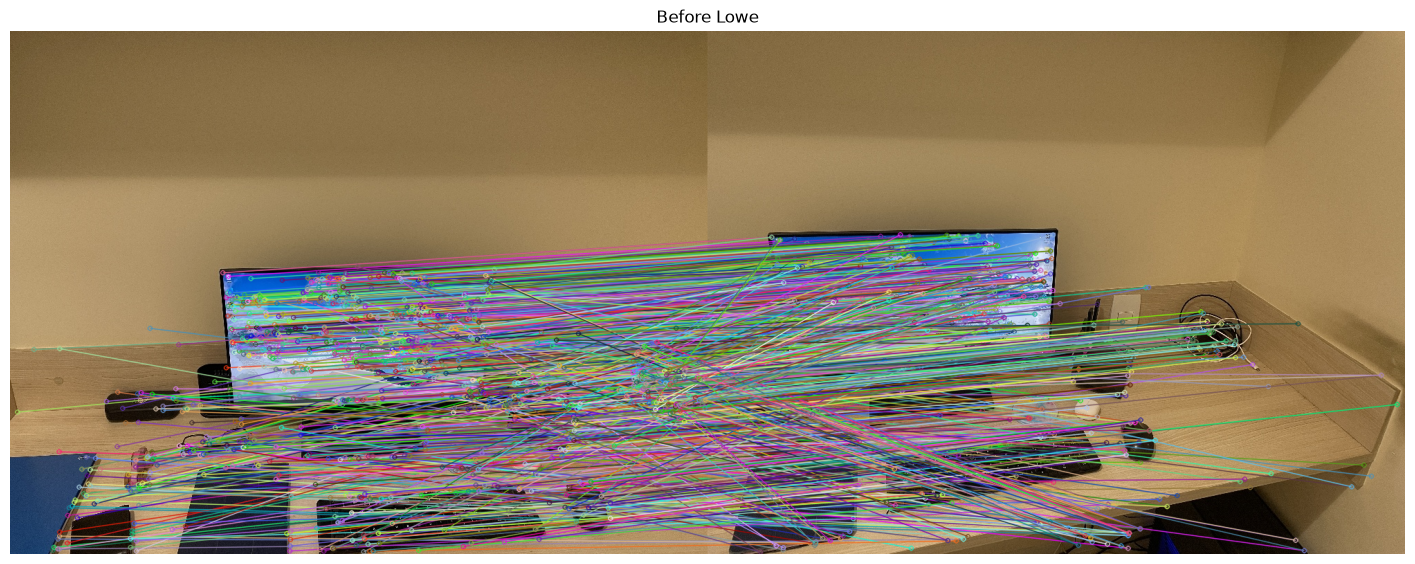

In [9]:
from src.visualization import plot_matches

i = 2
j = 5

plot_matches(images[i], # imagem sem os keypoints sobrepostos
            keypoints[i],
            images[j], 
            keypoints[j],
            matches_matrix[i][j], # matches associados ao par de imagens
            "Before Lowe")

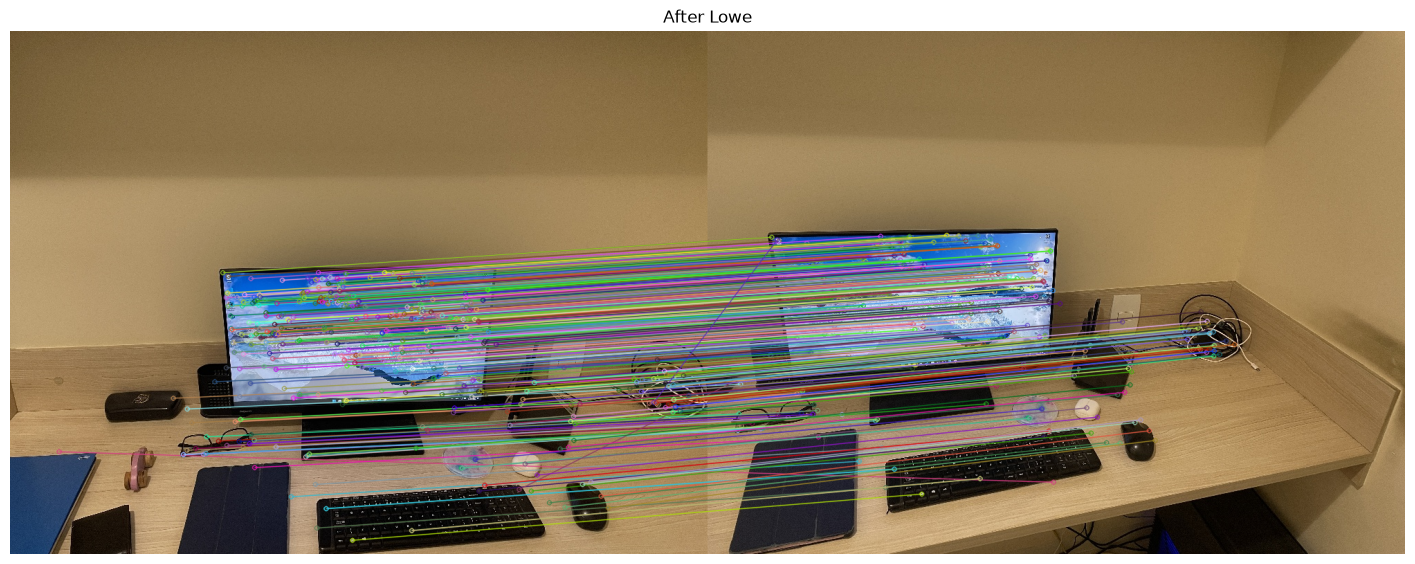

In [10]:
plot_matches(images[i], # imagem sem os keypoints sobrepostos
            keypoints[i], # keypoints
            images[j], 
            keypoints[j],
            lowe_matrix[i][j], # matches associados ao par de imagens, filtrados com teste da razão
            "After Lowe")

# Etapa 4

Ordenação automática

[3, 7, 6, 2, 5, 4, 0]


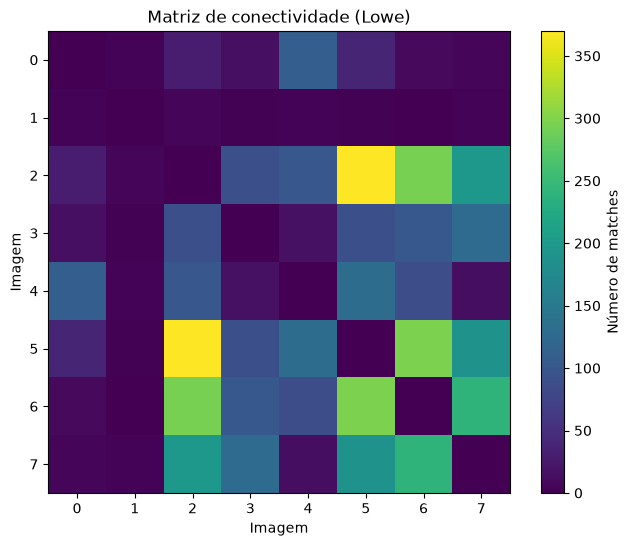

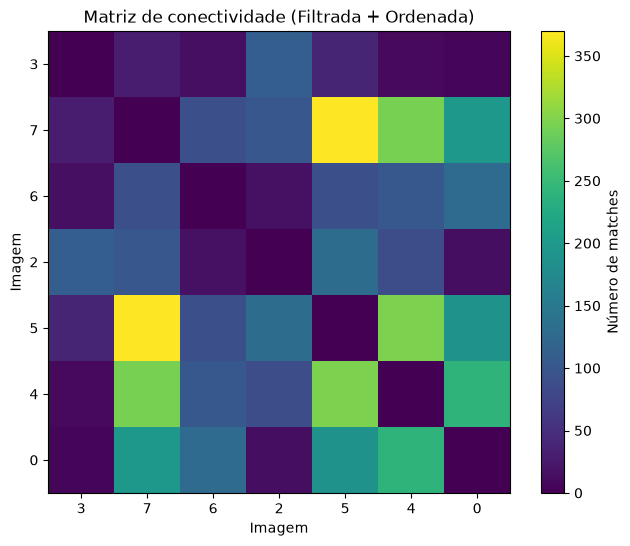

In [11]:
from src.ordering import infer_order
from src.visualization import plot_matrix

order, connectivity_matrix, filtered_matrix = infer_order(lowe_matrix, outlier_threshold=0.5) 

print(order)
plot_matrix(connectivity_matrix, title="Matriz de conectividade (Lowe)")
plot_matrix(filtered_matrix, title="Matriz de conectividade (Filtrada + Ordenada)", order=order)

# Etapa 5

Homografia e Alinhamento

In [12]:
from src.homography import estimate_all_homographies

homographies, homography_metrics = estimate_all_homographies(lowe_matrix, keypoints, order)

for metric in homography_metrics:

    print(
        f"{metric['src_index']} -> {metric['dst_index']} | "
        f"matches = {metric['num_matches']} | "
        f"inliers = {metric['num_inliers']} | "
        f"inlier rate = {metric['inlier_rate']:.2%} | "
        f"erro médio = "
        f"{metric['mean_reprojection_error']:.2f} px"
    )

Processando: imagem 3 → imagem 7
Processando: imagem 7 → imagem 6
Processando: imagem 6 → imagem 2
Processando: imagem 2 → imagem 5
Processando: imagem 5 → imagem 4
Processando: imagem 4 → imagem 0
3 -> 7 | matches = 129 | inliers = 105 | inlier rate = 81.40% | erro médio = 0.99 px
7 -> 6 | matches = 241 | inliers = 193 | inlier rate = 80.08% | erro médio = 0.93 px
6 -> 2 | matches = 294 | inliers = 242 | inlier rate = 82.31% | erro médio = 0.77 px
2 -> 5 | matches = 370 | inliers = 339 | inlier rate = 91.62% | erro médio = 0.82 px
5 -> 4 | matches = 131 | inliers = 83 | inlier rate = 63.36% | erro médio = 0.86 px
4 -> 0 | matches = 111 | inliers = 85 | inlier rate = 76.58% | erro médio = 1.07 px


Par analisado: imagem 0 -> imagem 4
Processando: imagem 0 → imagem 4
Processando: imagem 0 → imagem 4
Processando: imagem 0 → imagem 4


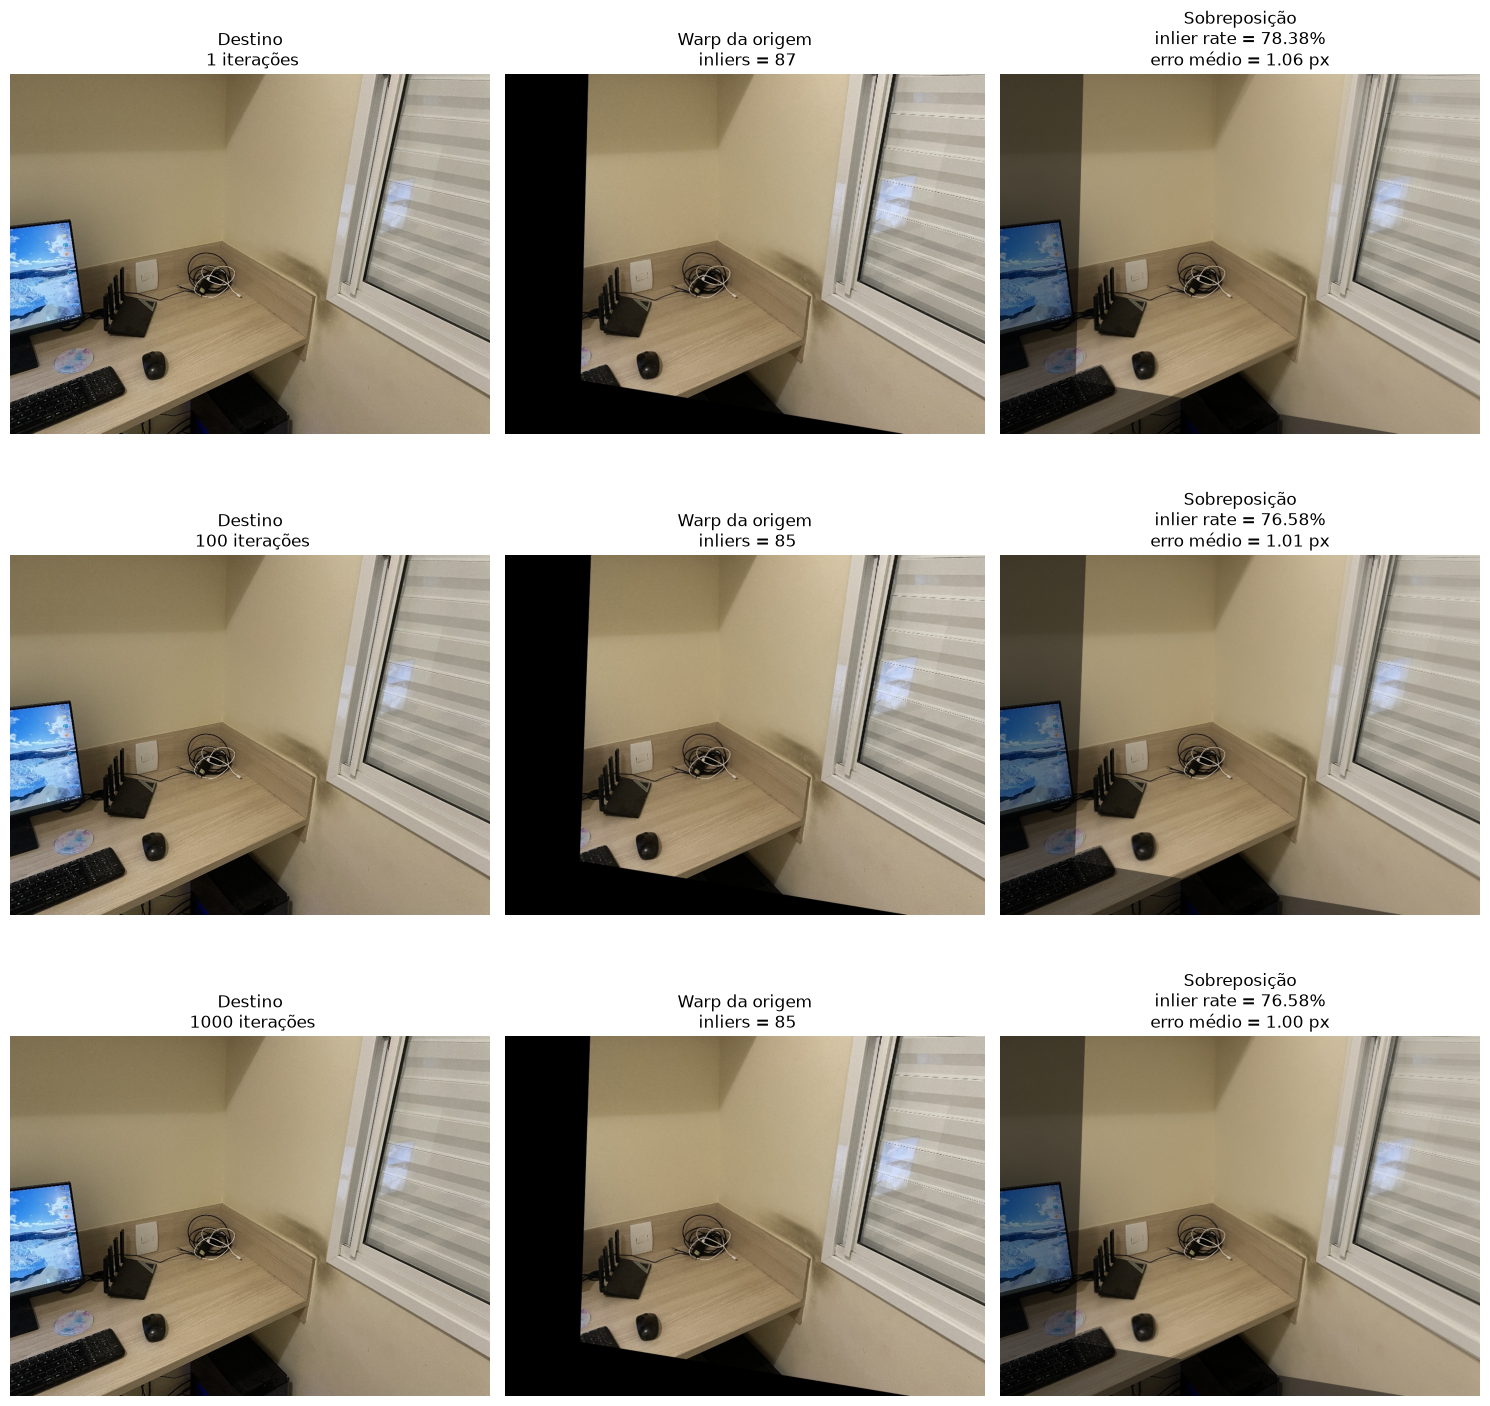

In [13]:
from src.visualization import plot_iterations

i = 0
j = 4

print(f"Par analisado: imagem {i} -> imagem {j}")
iteration_values = [1, 100, 1000]
results = []

for num_iterations in iteration_values:
    H, pair_metrics = estimate_all_homographies(lowe_matrix, keypoints, [i, j])

    results.append({
        "iterations": num_iterations,
        "H": H[0],
        "metrics": pair_metrics[0]
    })

image_src = images[i]
image_dst = images[j]

plot_iterations(images[i], images[j], results)

# Etapa 6: Composição, blending, deghosting

In [14]:
from src.composition import cylindrical_stitching
from src.blending import optimal_seam_blending

warps, masks, info = cylindrical_stitching(images, order, homographies, 750)

Canvas: 1903 × 825
Projetando imagem 3 (posição 0)
Projetando imagem 7 (posição 1)
Projetando imagem 6 (posição 2)
Projetando imagem 2 (posição 3)
Projetando imagem 5 (posição 4)
Projetando imagem 4 (posição 5)
Projetando imagem 0 (posição 6)


Blending: imagem 1 + panorama
Blending: imagem 2 + panorama
Blending: imagem 3 + panorama
Blending: imagem 4 + panorama
Blending: imagem 5 + panorama
Blending: imagem 6 + panorama


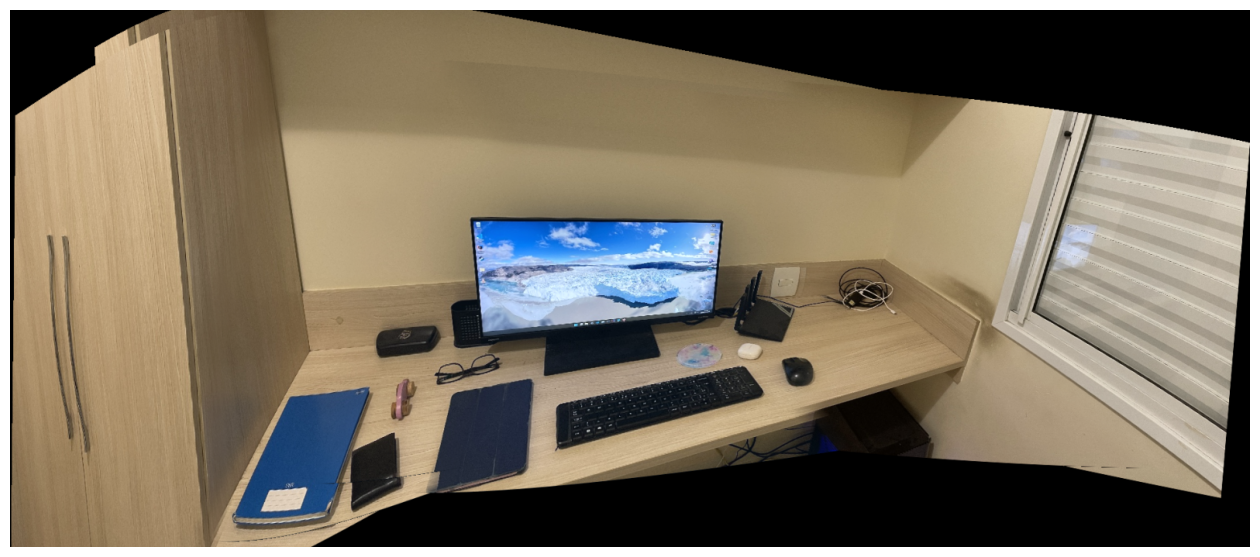

In [15]:
from src.visualization import plot_image

plot_image(optimal_seam_blending(warps, masks))